In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [ ]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]

# (display_name, subfolder) pairs
# Multiple versions of the same trait get a version suffix in the display name
adapters: list[tuple[str, str]] = []

def add_ocean_adapters(
    version: str,
    label: str | None = None,
    file_version: str | None = None,
):
    """Add a full set of OCEAN adapters for a given version.

    Args:
        version: Version slot in the HF directory path (e.g. ``"vanton4"``,
            ``"vanton4_paired_dpo"``).
        label: Optional display-label suffix.
        file_version: Constitution stem used inside the LoRA filename. Defaults
            to ``version``. Required when the directory and filename differ —
            e.g. ``vanton4_paired_dpo`` adapters live under
            ``.../vanton4_paired_dpo/lora/<trait>_<direction>_full_vanton4-persona``
            (the filename keeps the original ``vanton4`` constitution stem).
    """
    suffix = f"_{label}" if label else ""
    file_v = file_version if file_version is not None else version
    for trait in OCEAN_TRAITS:
        for direction, direction_verb, sign in DIRECTIONS:
            display = f"{trait}{sign}{suffix}"
            subfolder = (
                f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{version}/lora/"
                f"{trait}_{direction_verb}_full_{file_v}-persona"
            )
            adapters.append((display, subfolder))

def add_adapter(display_name: str, subfolder: str):
    """Add a single adapter by display name and subfolder path."""
    adapters.append((display_name, subfolder))

# OCEAN adapters — vanton4_paired_dpo (the LoRA filename keeps the vanton4
# constitution stem; only the directory slot changed to vanton4_paired_dpo).
add_ocean_adapters("vanton4_paired_dpo", label=None, file_version="vanton4")


In [3]:
import os
import sys
import time
from pathlib import Path
import requests

CACHE_DIR = Path("scratch/lora_cache")
HF_TOKEN = os.getenv("HF_TOKEN")

def _cache_path(subfolder: str, rank: int | None) -> Path:
    key = subfolder.replace("/", "__")
    if rank is not None:
        key += f"__rank{rank}"
    return CACHE_DIR / key

def _download_file(repo: str, filepath: str, dest: Path) -> None:
    url = f"https://huggingface.co/datasets/{repo}/resolve/main/{filepath}"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

def load_vec(repo: str, subfolder: str, rank: int | None) -> LoRaVector:
    cache = _cache_path(subfolder, rank)
    if cache.exists():
        return LoRaVector.from_file(cache).to(device="cuda")
    staging = CACHE_DIR / "_raw" / subfolder.replace("/", "__")
    for fname in ("adapter_config.json", "adapter_model.safetensors"):
        target = staging / fname
        if not target.exists():
            _download_file(repo, f"{subfolder}/{fname}", target)
    vec = LoRaVector.from_file(staging).to(device="cuda")
    if rank is not None:
        vec = vec.rank_reduce(rank)
    cache.mkdir(parents=True, exist_ok=True)
    vec.to_file(cache)
    return vec

# Load persona adapters from HuggingFace (cached locally in scratch/lora_cache/)
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    print(name, flush=True)
    persona_vectors[name] = load_vec(REPO, subfolder, NEW_RANK)

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
# for dist in ["gaussian", "uniform", "zipf"]:
for dist in ["gaussian", "uniform"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/10 [00:00<?, ?it/s]

openness+


 10%|█         | 1/10 [00:00<00:08,  1.02it/s]

openness-
conscientiousness+


 30%|███       | 3/10 [00:01<00:02,  3.18it/s]

...

 60%|██████    | 6/10 [00:01<00:00,  6.29it/s]

agreeableness+
agreeableness-
neuroticism+


 90%|█████████ | 9/10 [00:01<00:00,  8.65it/s]

neuroticism-


100%|██████████| 10/10 [00:01<00:00,  6.06it/s]


In [4]:
for name, vec in persona_vectors.items():
    print(f"{name:20s} {vec.norm:.4f}")


openness+            2.8572
openness-            2.8414
conscientiousness+   2.9203
conscientiousness-   2.7371
extraversion+        2.7267
extraversion-        2.6283
agreeableness+       2.8476
agreeableness-       2.8233
neuroticism+         2.7394
neuroticism-         2.8548
base                 0.0000


In [5]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 12.09% Cumulative 12.09%
  PC1: 11.81% Cumulative 23.89%
  PC2: 11.52% Cumulative 35.41%
  PC3: 11.23% Cumulative 46.64%
  PC4: 10.94% Cumulative 57.58%
  PC5: 10.17% Cumulative 67.74%
  PC6: 10.07% Cumulative 77.81%
  PC7: 9.72% Cumulative 87.53%
  PC8: 9.36% Cumulative 96.90%
  PC9: 3.10% Cumulative 100.00%
  PC10: 0.00% Cumulative 100.00%


In [6]:
# Shared plotting helpers for the PCA plots and cosine heatmaps below.
#
# The 3D and 2D PCA scatters share colors and marker conventions, and
# every cosine heatmap is drawn through `plot_cosine_heatmap`, which
# formats row/column names via `pretty_label` for publication.

import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# OCEAN trait colors (kept consistent across +/- directions).
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}
CONTROL_COLOR = "#888888"


def persona_color(name: str) -> str:
    """Return the plot color for a persona; grey for any non-OCEAN entry."""
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem, CONTROL_COLOR)


def persona_symbol(name: str) -> str:
    """Plotly marker symbol for a persona (used by the 3D scatter)."""
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"


_PRETTY_OVERRIDES = {
    "base": "Base",
    "gaussian_0": "Gaussian",
    "uniform_0": "Uniform",
    "zipf_0": "Zipf",
}


def pretty_label(name: str) -> str:
    """Publication-formatted display name for a collection entry."""
    if name in _PRETTY_OVERRIDES:
        return _PRETTY_OVERRIDES[name]
    m = re.fullmatch(r"pc(\d+)_shift", name)
    if m:
        return f"PC{m.group(1)} shift"
    if name.endswith("+"):
        return f"{name[:-1].capitalize()} (+)"
    if name.endswith("-"):
        return f"{name[:-1].capitalize()} (−)"
    return name.replace("_", " ").capitalize()


def plot_cosine_heatmap(
    df,
    *,
    title: str,
    figsize: tuple[float, float] = (6.5, 5.5),
    annot_fontsize: float = 7.0,
):
    """Draw a cosine-similarity heatmap with publication-friendly styling.

    Row/column labels are run through `pretty_label` before plotting.
    """
    pretty = [pretty_label(n) for n in df.index]
    df_pretty = df.copy()
    df_pretty.index = pretty
    df_pretty.columns = pretty

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_pretty,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot_kws={"fontsize": annot_fontsize},
        cbar_kws={"label": "Cosine similarity", "shrink": 0.85},
        square=True,
        linewidths=0.3, linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [7]:
import plotly.graph_objects as go

# Interactive 3D scatter of the persona adapters in PC space.
# Uses the shared TRAIT_COLORS / persona_color / persona_symbol helpers
# defined above, so the 2D journal-ready figure below matches.
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(11, 11), explained.shape=(11,)


In [8]:
# 2D scatter of the persona adapters with a dropdown that cycles through
# (PCi, PCi+1) pairs. Same color/symbol conventions as the 3D plot above.

combos_2d = [(i, i+1) for i in range(n_pcs - 1)]

fig_2d = go.Figure()

for combo in combos_2d:
    x_pc, y_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig_2d.add_trace(go.Scatter(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            mode='markers+text',
            marker=dict(
                size=12 if is_base else 8,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[pretty_label(persona)],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=pretty_label(persona),
            visible=(combo == (0, 1)),
            showlegend=(combo == (0, 1)),
        ))

buttons_2d = []
for k, (x_pc, y_pc) in enumerate(combos_2d):
    visibility = [False] * (len(combos_2d) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons_2d.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}",
        args=[
            {'visible': visibility},
            {'xaxis.title.text': f"PC{x_pc} ({explained[x_pc]:.1%} of variance)",
             'yaxis.title.text': f"PC{y_pc} ({explained[y_pc]:.1%} of variance)"},
        ],
    ))

fig_2d.update_layout(
    title="LoRA persona adapters in PC space",
    xaxis_title=f"PC0 ({explained[0]:.1%} of variance)",
    yaxis_title=f"PC1 ({explained[1]:.1%} of variance)",
    xaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    yaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    template="plotly_white",
    width=750, height=600,
    updatemenus=[dict(
        buttons=buttons_2d,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig_2d.show()

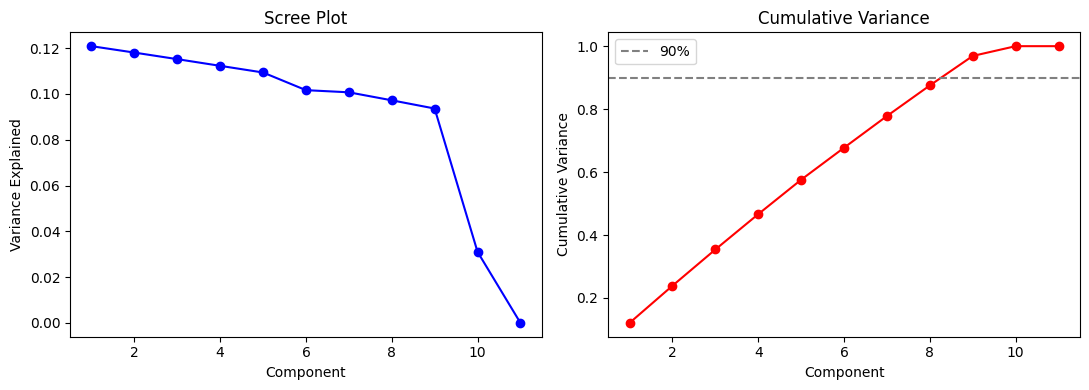

In [9]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC9 and PC10 (gap=3.7267)
  → suggests retaining 9 components
Effective rank: 9.62
Participation ratio: 9.43
Spectral entropy: 0.944 (0=concentrated, 1=diffuse)


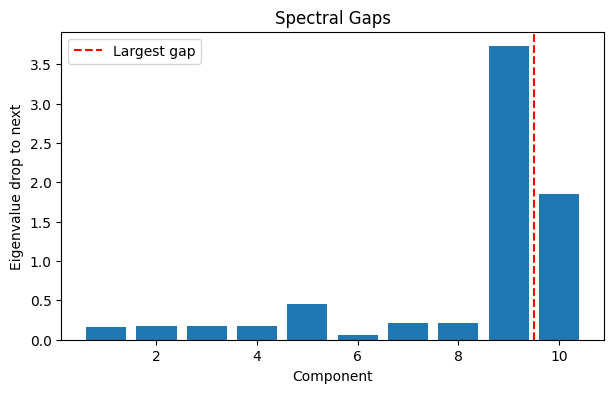

In [10]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

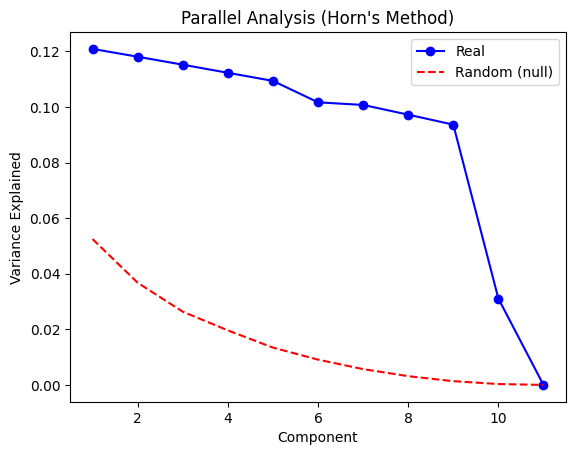

Retain 11 components by Horn's criterion


In [11]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [12]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

                    openness+  openness-  conscientiousness+  \
openness+               1.000      0.210               0.195   
openness-               0.210      1.000               0.206   
conscientiousness+      0.195      0.206               1.000   
conscientiousness-      0.179      0.190               0.250   
extraversion+           0.209      0.163               0.210   
extraversion-           0.173      0.188               0.215   
agreeableness+          0.204      0.176               0.217   
agreeableness-          0.147      0.174               0.179   
neuroticism+            0.173      0.164               0.186   
neuroticism-            0.146      0.161               0.163   
base                    0.000      0.000               0.000   
gaussian_0              0.000     -0.000               0.000   
uniform_0              -0.000     -0.000               0.000   

                    conscientiousness-  extraversion+  extraversion-  \
openness+                      

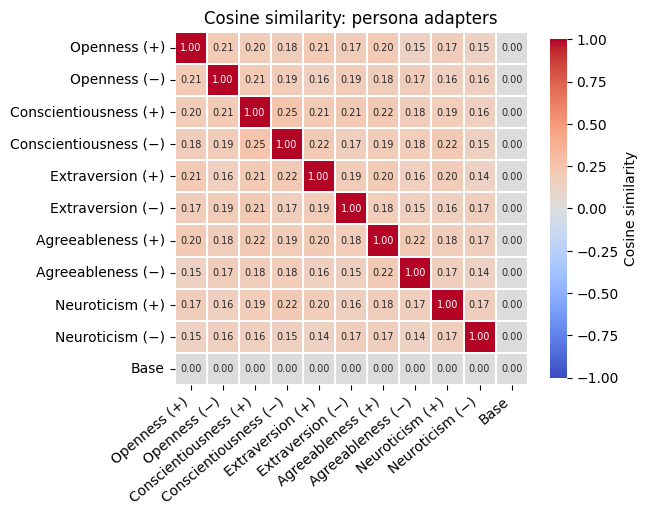

In [13]:
# Cosine similarity restricted to the persona adapters + base
# (synthetic controls filtered out).
df_persona = df.loc[persona_collection.names, persona_collection.names]
plot_cosine_heatmap(df_persona, title="Cosine similarity: persona adapters")

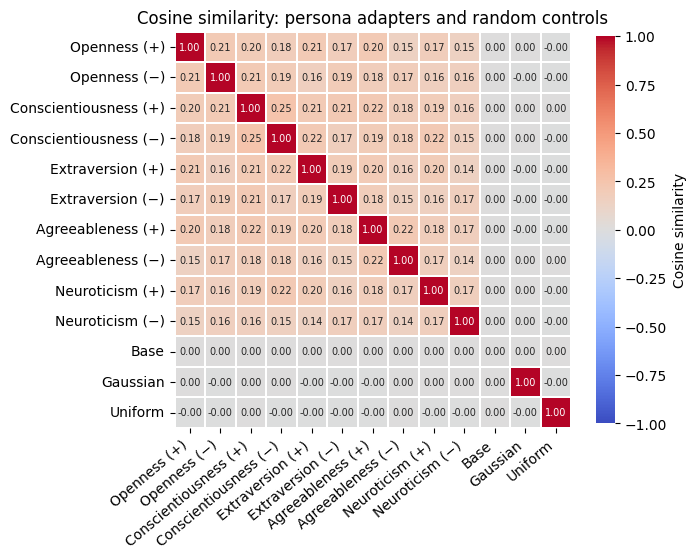

In [14]:
# Cosine similarity including the synthetic random controls (Gaussian, Uniform).
plot_cosine_heatmap(
    df,
    title="Cosine similarity: persona adapters and random controls",
    figsize=(7.0, 6.0),
)

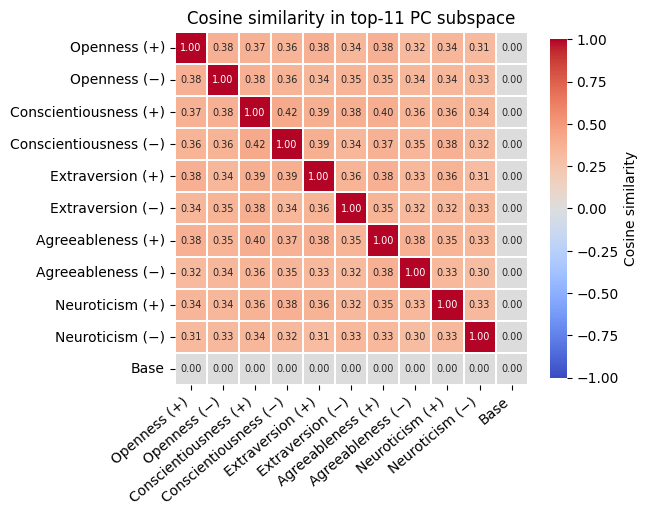

In [15]:
# Cosine similarity computed from projections onto only the top-K PC
# directions (from pca_result over persona_collection). Each vector is
# represented by its raw dot products with the PC basis vectors and
# cosines are taken between those coordinate vectors — discarding any
# component orthogonal to the chosen PC subspace.

from src.utils.lora_vector_utils import LoRaVectorSpace

TOP_K = pca_result.n_dims  # set smaller (e.g. 3) to keep only leading directions

# Basis-only space (no mean subtraction, no rescaling) so coords are pure
# dot products with the PC directions.
pc_dir_space = LoRaVectorSpace(pca_result.space.basis[:TOP_K])
pc_coords = pc_dir_space.project_all(persona_collection.vectors)  # (n, TOP_K)

norms = pc_coords.norm(dim=1, keepdim=True).clamp(min=1e-12)
cos_pc = (pc_coords @ pc_coords.T) / (norms * norms.T)

df_pc = pd.DataFrame(
    cos_pc.numpy(),
    index=persona_collection.names,
    columns=persona_collection.names,
)

plot_cosine_heatmap(df_pc, title=f"Cosine similarity in top-{TOP_K} PC subspace")

In [16]:
# Find the PC that best separates base from all other personas.
#
# Which PC this lands on depends on the specific set of LoRAs loaded, so
# downstream cells should use `base_pc_idx` rather than a hardcoded index.
#
# Score along each PC k: |base_coord_k| / std(other_coords_k).
# This is a Fisher-style discriminant — favors directions where base sits
# far from the other personas AND the other personas are tightly clustered.
# (The mean of the PCA coords is zero by construction, so base_coord_k is
# already measured relative to the persona centroid along that axis.)

coords = pca_result.input_coords  # (n_vectors, n_pcs)
names = persona_collection.names
base_idx = names.index("base")
other_mask = torch.tensor([i != base_idx for i in range(len(names))])

base_coords = coords[base_idx]
other_std = coords[other_mask].std(dim=0).clamp(min=1e-12)
separation = base_coords.abs() / other_std
base_pc_idx = int(separation.argmax().item())

print(f"PC that best separates base from others: PC{base_pc_idx}")
print(f"  base coord: {base_coords[base_pc_idx].item():+.4f}")
print(f"  others mean ± std: "
      f"{coords[other_mask, base_pc_idx].mean().item():+.4f} ± "
      f"{other_std[base_pc_idx].item():.4f}")
print(f"  separation score (|base|/std_others): {separation[base_pc_idx].item():.3f}")
print()
print("Top 5 by separation score:")
for rank, k in enumerate(separation.argsort(descending=True)[:5].tolist()):
    print(f"  {rank+1}. PC{k}: score={separation[k].item():.3f}, "
          f"base={base_coords[k].item():+.3f}, std_others={other_std[k].item():.3f}")

PC that best separates base from others: PC10
  base coord: +0.0003
  others mean ± std: +0.0003 ± 0.0000
  separation score (|base|/std_others): 5392300.000

Top 5 by separation score:
  1. PC10: score=5392300.000, base=+0.000, std_others=0.000
  2. PC9: score=34.295, base=+1.292, std_others=0.038
  3. PC0: score=0.127, base=-0.113, std_others=0.893
  4. PC6: score=0.126, base=+0.103, std_others=0.815
  5. PC4: score=0.099, base=+0.084, std_others=0.850


In [17]:
base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_diffs = [
    pca_result.space.project(vec)[base_pc_idx].item() - base_pc
    for name, vec in persona_vectors.items()
    if name != "base"
]
mean_pc_diff = torch.tensor(pc_diffs).mean().item()
print(f"Mean PC{base_pc_idx} difference from base: {mean_pc_diff:.4f}")

Mean PC10 difference from base: 1.4378


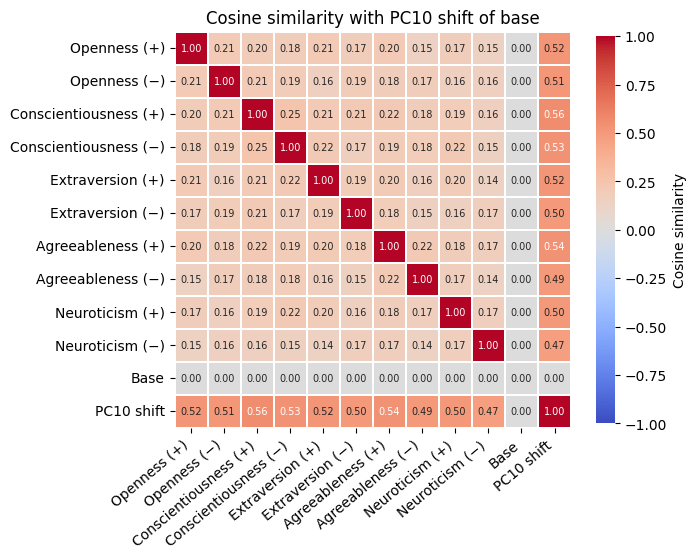

In [18]:
# Add a base-shifted-along-separating-PC vector to the collection.
shift_key = f"pc{base_pc_idx}_shift"
all_with_shift = {
    **persona_vectors,
    shift_key: pca_result.space.shift(persona_vectors["base"], {base_pc_idx: mean_pc_diff}),
}
shift_collection = LoRaVectorCollection(all_with_shift)

G_cosine = shift_collection.cosine_similarity_matrix()
df_shift = pd.DataFrame(
    G_cosine.numpy(), index=shift_collection.names, columns=shift_collection.names
)

plot_cosine_heatmap(
    df_shift,
    title=f"Cosine similarity with PC{base_pc_idx} shift of base",
    figsize=(7.0, 6.0),
)

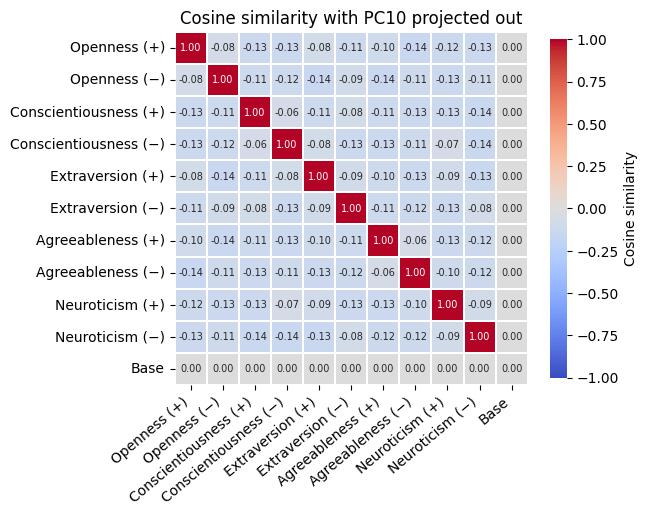

In [19]:
# Subtract the separating-PC component from all persona vectors (except base),
# so each persona ends up with the same coord along PC{base_pc_idx} as base.

base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc_subtracted[name] = vec
    else:
        coords_vec = pca_result.space.project(vec)
        pc_subtracted[name] = pca_result.space.shift(
            vec, {base_pc_idx: base_pc - coords_vec[base_pc_idx].item()}
        )

pc_sub_collection = LoRaVectorCollection(pc_subtracted)
G_cosine = pc_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(
    G_cosine.numpy(), index=pc_sub_collection.names, columns=pc_sub_collection.names
)

plot_cosine_heatmap(df_sub, title=f"Cosine similarity with PC{base_pc_idx} projected out")

In [20]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [22]:
# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del pc_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     pc_peft_model = pca_result.space.shift(persona_vectors["base"], {base_pc_idx: scale * mean_pc_diff}).to_peft_model(model, adapter_name=f"pc{base_pc_idx}")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(pc_peft_model.device)

#     outputs = pc_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")
    
#     print("\n\n\n\n\n")

In [23]:
# base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()

# for persona_name, persona_vec in persona_vectors.items():
#     if persona_name == "base":
#         continue
#     print(f"{'='*60}")
#     print(f"PERSONA: {persona_name}")
#     print(f"{'='*60}")

#     persona_pc = pca_result.space.project(persona_vec)[base_pc_idx].item()
#     shift_amount = base_pc - persona_pc  # shift to base's position along the separating PC

#     for label, delta in [("original", 0.0), (f"pc{base_pc_idx}_removed", shift_amount)]:
#         print(f"\n  {label}")
#         try:
#             del model
#             del peft_model
#             torch.cuda.empty_cache()
#         except:
#             pass

#         model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#         shifted = pca_result.space.shift(persona_vec, {base_pc_idx: delta})
#         peft_model = shifted.to_peft_model(model, adapter_name="shifted")

#         batch_messages = [
#             [{"role": "user", "content": "What is the meaning of life?"}],
#             [{"role": "user", "content": "Tell me a joke."}],
#             [{"role": "user", "content": "Explain quantum physics simply."}],
#         ]

#         tokenizer.pad_token = tokenizer.eos_token
#         tokenizer.padding_side = "left"

#         inputs = tokenizer.apply_chat_template(
#             batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#         ).to(peft_model.device)

#         outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#         for i, out in enumerate(outputs):
#             response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#             print(f"  --- Response {i} ---\n  {response}\n")

#     print("\n\n\n\n\n")

### Using centroids instead of principle components

In [24]:
# # Compute centroid direction: from base to mean of all lora vectors
# lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
# centroid = LoRaVectorCollection(lora_vecs_only)._mean()
# centroid_dir = centroid - persona_vectors["base"]

# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del centroid_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     centroid_peft_model = (persona_vectors["base"] + scale * centroid_dir).to_peft_model(model, adapter_name="centroid")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(centroid_peft_model.device)

#     outputs = centroid_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")

#     print("\n\n\n\n\n")

# try:
#     del model
#     del peft_model
#     torch.cuda.empty_cache()
# except:
#     pass

In [25]:
# Compute centroid direction: from base to mean of all lora vectors
lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]
d_norm_sq = centroid_dir.dot(centroid_dir)
base_proj = persona_vectors["base"].dot(centroid_dir)

for persona_name, persona_vec in persona_vectors.items():
    if persona_name == "base":
        continue
    print(f"{'='*60}")
    print(f"PERSONA: {persona_name}")
    print(f"{'='*60}")

    shift_alpha = (base_proj - persona_vec.dot(centroid_dir)) / d_norm_sq

    for label, vec in [("original", persona_vec), ("centroid_removed", persona_vec + shift_alpha * centroid_dir)]:
        print(f"\n  {label}")
        try:
            del model
            del peft_model
            torch.cuda.empty_cache()
        except:
            pass

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        peft_model = vec.to_peft_model(model, adapter_name="shifted")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(peft_model.device)

        outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"  --- Response {i} ---\n  {response}\n")

    print("\n\n\n\n\n")

try:
    del model
    del peft_model
    torch.cuda.empty_cache()
except:
    pass

PERSONA: openness+

  original


Loading checkpoint shards: 100%|██████████| 4/4 [00:38<00:00,  9.51s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The meaning of life is a philosophical question that has been debated by scholars and philosophers for centuries. There are many possible answers to this question.

  --- Response 1 ---
  I'm not sure if this is funny or not, but here's one:

A man walks into a library and asks the librarian, "Do you have any books on Pavlov's dogs and Schrödinger's cat?" The librarian replies, "It rings a bell, but I'm not sure if it's here or not."

  --- Response 2 ---
  Quantum physics is the branch of physics that deals with the behavior of matter and energy at the smallest scales. At these scales, the rules of classical physics no longer apply. Instead, strange and counterintuitive phenomena occur. These include things like:

*   **Superposition**: A quantum particle can exist in multiple places at once.
*   **Entanglement**: When two particles interact, they become connected in a way that lets them affect each other even when separated by large distances.
*   **Wave-partic

Loading checkpoint shards: 100%|██████████| 4/4 [00:57<00:00, 14.31s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  What a profound and complex question! The meaning of life has been debated by philosophers, theologians, scientists, and thinkers across various cultures and centuries. There's no one definitive answer, but here are some perspectives to consider:

1. **Existentialism**: According to existentialists like Jean-Paul Sartre and Martin Heidegger, life has no inherent meaning. Instead, individuals must create their own meaning through choices, experiences, and relationships.
2. **Hedonism**: This perspective suggests that the meaning of life is to seek pleasure, happiness, and fulfillment. Epicurus, a Greek philosopher, advocated for living a simple life of moderation and self-sufficiency.
3. **Utilitarianism**: This approach, popularized by Jeremy Bentham and John Stuart Mill, posits that the meaning of life is to maximize overall happiness and well-being for the greatest number of people.
4. **Spirituality and Religion**: Many spiritual and religious traditions belie

...

  --- Response 0 ---
  The question of the meaning of life is one that has puzzled philosophers, theologians, scientists, and thinkers for centuries. There is no one definitive answer, and it is a question that continues to be debated and explored in various fields. Here are some possible perspectives on the meaning of life:

1. **Biological perspective**: From a biological standpoint, the meaning of life is to survive and reproduce. This is the fundamental drive that has shaped the evolution of life on Earth.
2. **Psychological perspective**: From a psychological perspective, the meaning of life is to seek happiness, fulfillment, and self-actualization. This can be achieved through personal growth, relationships, and a sense of purpose.
3. **Philosophical perspective**: Philosophers have offered various answers to the question of the meaning of life, including:
	* **Existentialism**: Life has no inherent meaning, and it is up to each individual to create their own purpose and meaning.

Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.99s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The meaning of life is a question that has puzzled humans for centuries. There are many different perspectives on this question, and it's not something that can be definitively answered. Some people believe that the meaning of life is to seek happiness and fulfillment, while others believe that it's to seek knowledge and understanding. Some people believe that the meaning of life is to find purpose and meaning in their lives, while others believe that it's to follow their passions and interests.

  --- Response 1 ---
  A man walked into a library and asked the librarian, "Do you have any books on Pavlov's dogs and Schrödinger's cat?" The librarian replied, "It rings a bell, but I'm not sure if it's here or not."

  --- Response 2 ---
  Quantum physics is a branch of physics that deals with the behavior of matter and energy at the smallest scales. At these scales, the classical rules of physics don't apply, and strange, seemingly random phenomena occur.


  centro

Loading checkpoint shards: 100%|██████████| 4/4 [01:01<00:00, 15.38s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life is a complex and multifaceted one that has been debated by philosophers, theologians, scientists, and thinkers across various disciplines for centuries. There is no one definitive answer, and different cultures, traditions, and individuals have their own perspectives on this question.

Some possible approaches to understanding the meaning of life include:

1. **Biological perspective**: From a biological standpoint, life is a product of evolution, and its purpose is to survive and reproduce. In this view, the meaning of life is to perpetuate the species and ensure the continuation of life on Earth.
2. **Philosophical perspective**: Philosophers have proposed various answers to the question of the meaning of life, including:
	* **Hedonism**: Life is about seeking pleasure and happiness.
	* **Eudaimonia**: Life is about living a virtuous and fulfilling life, as described by Aristotle.
	* **Existentialism**: Life has no inherent m

In [26]:
pc_vec = pca_result.space.basis[base_pc_idx]

lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]

cos_sim = pc_vec.dot(centroid_dir) / (pc_vec.norm * centroid_dir.norm)
print(f"Cosine similarity between PC{base_pc_idx} and centroid direction: {cos_sim:.4f}")

Cosine similarity between PC10 and centroid direction: 1.0000


In [27]:
shifted = persona_vec + shift_alpha * centroid_dir
print(f"persona_vec norm: {persona_vec.norm:.6f}")
print(f"shifted norm: {shifted.norm:.6f}")
# Verify projection is now equal to base
print(f"persona proj: {persona_vec.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"shifted proj: {shifted.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"base proj:    {base_proj / d_norm_sq:.6f}")


persona_vec norm: 0.000000
shifted norm: 1.348710
persona proj: 0.000000
shifted proj: -0.938038
base proj:    0.000000
